# 02 | Exploration

This notebook is the exploratory stage of the project.

It answers the first descriptive questions:

- How do popularity and prestige relate?
- How unequal is attention on the profile side?
- Which profiles and raters stand out most strongly?

The purpose here is not yet to make the most specific substantive claim.
Instead, we build intuition with tables, rankings, and plots.


## Notebook Logic

This notebook uses the first-study pipeline.

If the required artifacts are missing, it can rebuild them by running the project analysis script.
By default, it reuses existing outputs to keep the notebook fast.


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "rec_dating_project").exists():
            return candidate
    raise RuntimeError("Could not locate the project root from the current working directory.")


project_root = locate_project_root()
sys.path.insert(0, str(project_root / "src"))

from rec_dating_project import PopularityPrestigeAnalyzer, ProjectPaths


paths = ProjectPaths.default()
paths.ensure_output_dirs()
OUTPUT_DATA = paths.output_data_dir
OUTPUT_FIGURES = paths.output_figures_dir
FORCE_REBUILD = False


def run_script(script_name: str, *args: str) -> None:
    cmd = [sys.executable, str(paths.scripts_dir / script_name), *args]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=paths.project_root)


def ensure_dataset_summary(force: bool = False) -> None:
    summary_path = OUTPUT_DATA / "dataset_summary.json"
    if force or not summary_path.exists():
        run_script("01_dataset_overview.py")


def ensure_first_study_outputs(force: bool = False) -> None:
    ensure_dataset_summary(force=force)
    required_data = [
        OUTPUT_DATA / "dataset_summary.json",
        OUTPUT_DATA / "rating_distribution_full.csv",
        OUTPUT_DATA / "profile_metrics_full.csv",
        OUTPUT_DATA / "profile_metrics_positive_8_full.csv",
        OUTPUT_DATA / "rater_metrics_full.csv",
        OUTPUT_DATA / "top_profiles_popularity_full.csv",
        OUTPUT_DATA / "top_profiles_prestige_full.csv",
        OUTPUT_DATA / "top_profiles_prestige_gap_positive_full.csv",
        OUTPUT_DATA / "top_profiles_prestige_gap_negative_full.csv",
        OUTPUT_DATA / "top_raters_activity_full.csv",
        OUTPUT_DATA / "top_raters_hub_full.csv",
    ]
    required_figures = [
        OUTPUT_FIGURES / "rating_distribution_full.png",
        OUTPUT_FIGURES / "strength_ccdf_full.png",
        OUTPUT_FIGURES / "popularity_vs_prestige_full.png",
        OUTPUT_FIGURES / "popularity_vs_prestige_2_full.png",
        OUTPUT_FIGURES / "profile_lorenz_full.png",
    ]
    missing = [path for path in required_data + required_figures if not path.exists()]
    if force or missing:
        run_script("04_full_project_analysis.py")


ensure_first_study_outputs(FORCE_REBUILD)

summary = json.loads((OUTPUT_DATA / "dataset_summary.json").read_text(encoding="utf-8"))
rating_distribution = pd.read_csv(OUTPUT_DATA / "rating_distribution_full.csv")
profile_metrics = pd.read_csv(OUTPUT_DATA / "profile_metrics_full.csv")
positive_profile_metrics = pd.read_csv(OUTPUT_DATA / "profile_metrics_positive_8_full.csv")
rater_metrics = pd.read_csv(OUTPUT_DATA / "rater_metrics_full.csv")
top_popularity = pd.read_csv(OUTPUT_DATA / "top_profiles_popularity_full.csv")
top_prestige = pd.read_csv(OUTPUT_DATA / "top_profiles_prestige_full.csv")
top_gap_positive = pd.read_csv(OUTPUT_DATA / "top_profiles_prestige_gap_positive_full.csv")
top_gap_negative = pd.read_csv(OUTPUT_DATA / "top_profiles_prestige_gap_negative_full.csv")
top_raters_activity = pd.read_csv(OUTPUT_DATA / "top_raters_activity_full.csv")
top_raters_hub = pd.read_csv(OUTPUT_DATA / "top_raters_hub_full.csv")


def top_overlap(frame: pd.DataFrame, col_a: str, col_b: str, k: int = 100) -> dict[str, float]:
    a = set(frame.sort_values(col_a, ascending=False).head(k)["profile_id"].tolist())
    b = set(frame.sort_values(col_b, ascending=False).head(k)["profile_id"].tolist())
    inter = len(a & b)
    union = len(a | b)
    return {"k": k, "intersection": inter, "jaccard": (inter / union) if union else 0.0}


full_corr = {
    "pearson": float(profile_metrics["in_strength"].corr(profile_metrics["authority_score"], method="pearson")),
    "spearman": float(profile_metrics["in_strength"].corr(profile_metrics["authority_score"], method="spearman")),
}
pos_corr = {
    "pearson": float(positive_profile_metrics["in_strength"].corr(positive_profile_metrics["authority_score"], method="pearson")),
    "spearman": float(positive_profile_metrics["in_strength"].corr(positive_profile_metrics["authority_score"], method="spearman")),
}
overlap = top_overlap(profile_metrics, "in_strength", "authority_score", k=100)
profile_ineq = {
    "gini_in_strength": PopularityPrestigeAnalyzer.gini(profile_metrics["in_strength"]),
    "gini_authority": PopularityPrestigeAnalyzer.gini(profile_metrics["authority_score"]),
    "top_1pct_in_strength_share": PopularityPrestigeAnalyzer.top_share(profile_metrics["in_strength"], fraction=0.01),
    "top_1pct_authority_share": PopularityPrestigeAnalyzer.top_share(profile_metrics["authority_score"], fraction=0.01),
}


## Core Exploration Summary

The table below collects the main descriptive numbers from the first study.


In [2]:
exploration_summary = pd.DataFrame(
    [
        {"metric": "Full-layer Pearson correlation", "value": full_corr["pearson"]},
        {"metric": "Full-layer Spearman correlation", "value": full_corr["spearman"]},
        {"metric": "Positive-layer Pearson correlation (rating >= 8)", "value": pos_corr["pearson"]},
        {"metric": "Positive-layer Spearman correlation (rating >= 8)", "value": pos_corr["spearman"]},
        {"metric": "Top-100 popularity/prestige overlap", "value": overlap["intersection"]},
        {"metric": "Top-100 popularity/prestige Jaccard", "value": overlap["jaccard"]},
        {"metric": "Gini of profile in-strength", "value": profile_ineq["gini_in_strength"]},
        {"metric": "Gini of profile authority", "value": profile_ineq["gini_authority"]},
        {"metric": "Top 1% share of in-strength", "value": profile_ineq["top_1pct_in_strength_share"]},
        {"metric": "Top 1% share of authority", "value": profile_ineq["top_1pct_authority_share"]},
    ]
)

display(exploration_summary)


,metric,value
0,Full-layer Pearson correlation,0.8435
1,Full-layer Spearman correlation,0.8551
2,Positive-layer Pearson correlation (rating >= 8),0.8703
3,Positive-layer Spearman correlation (rating >= 8),0.7986
4,Top-100 popularity/prestige overlap,75.0000
5,Top-100 popularity/prestige Jaccard,0.6000
6,Gini of profile in-strength,0.8311
7,Gini of profile authority,0.8107
8,Top 1% share of in-strength,0.3457
9,Top 1% share of authority,0.2649


## Visual Exploration

We now inspect the key figures one by one.

The first two plots show how the rating scale is used and how heavy-tailed the interaction distribution is.
The next three focus on popularity, prestige, and inequality on the profile side.


### rating_distribution_full.png

The rating scale is used unevenly, with substantial mass near the upper end.

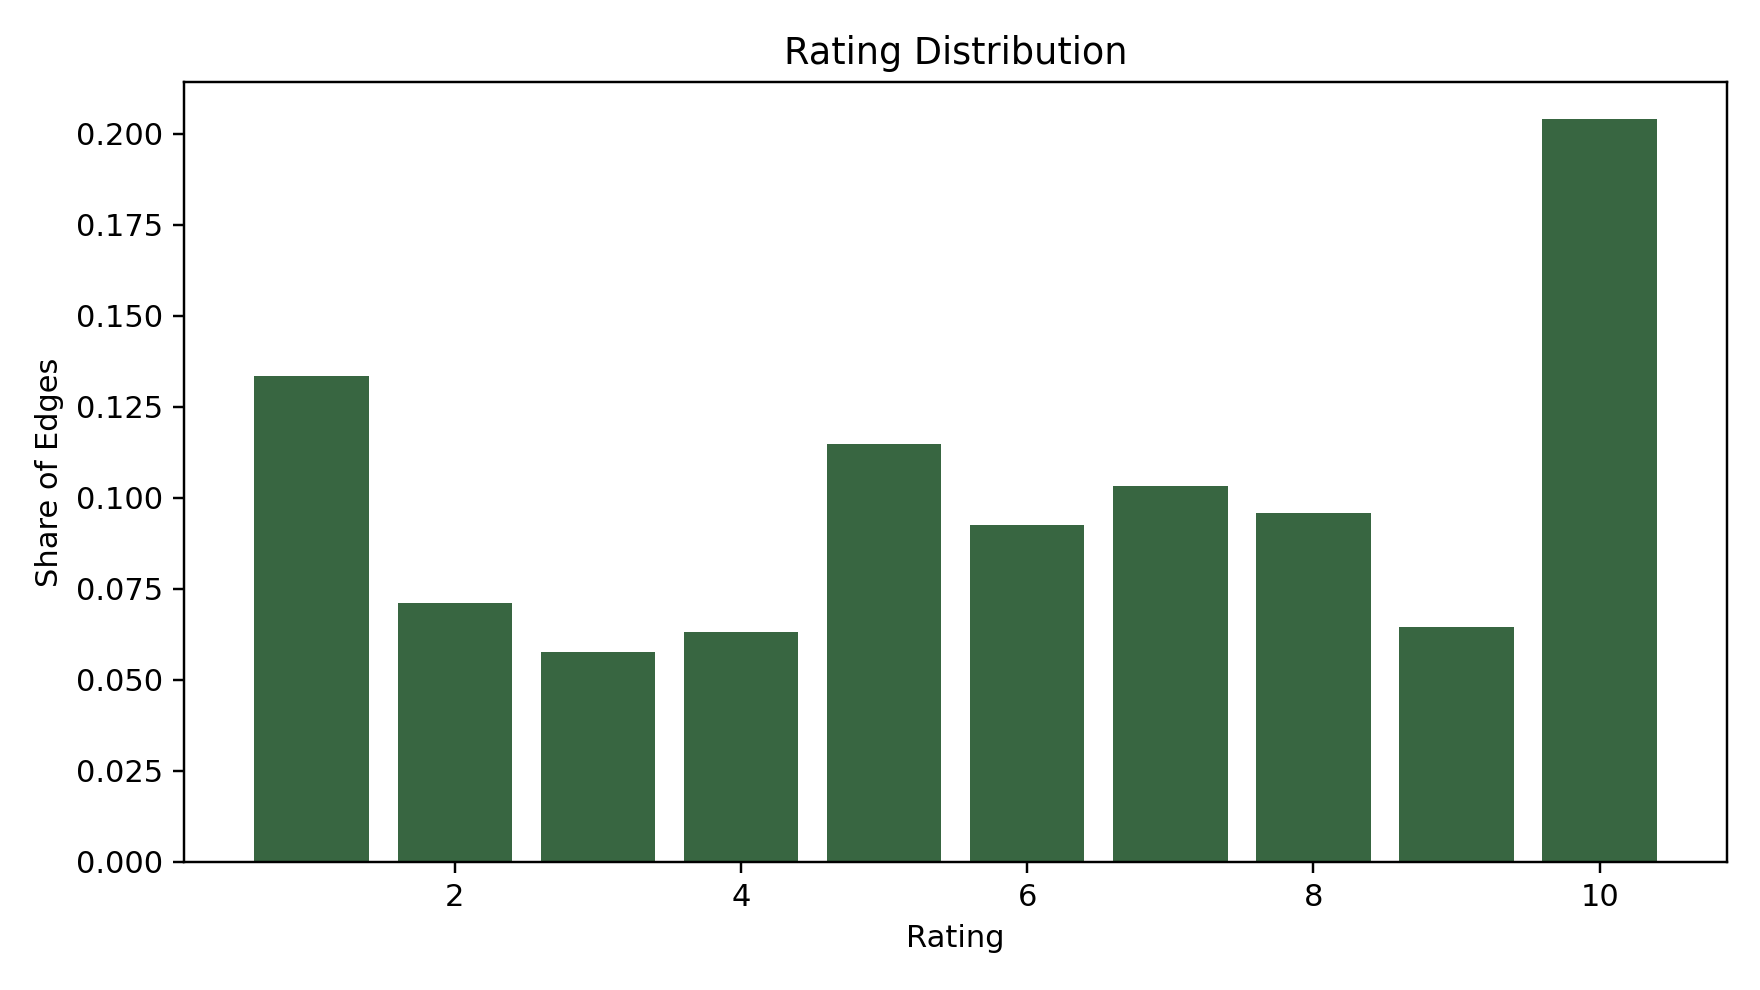

### strength_ccdf_full.png

Interaction is heavy-tailed on both sides of the bipartite graph, especially on the profile side.

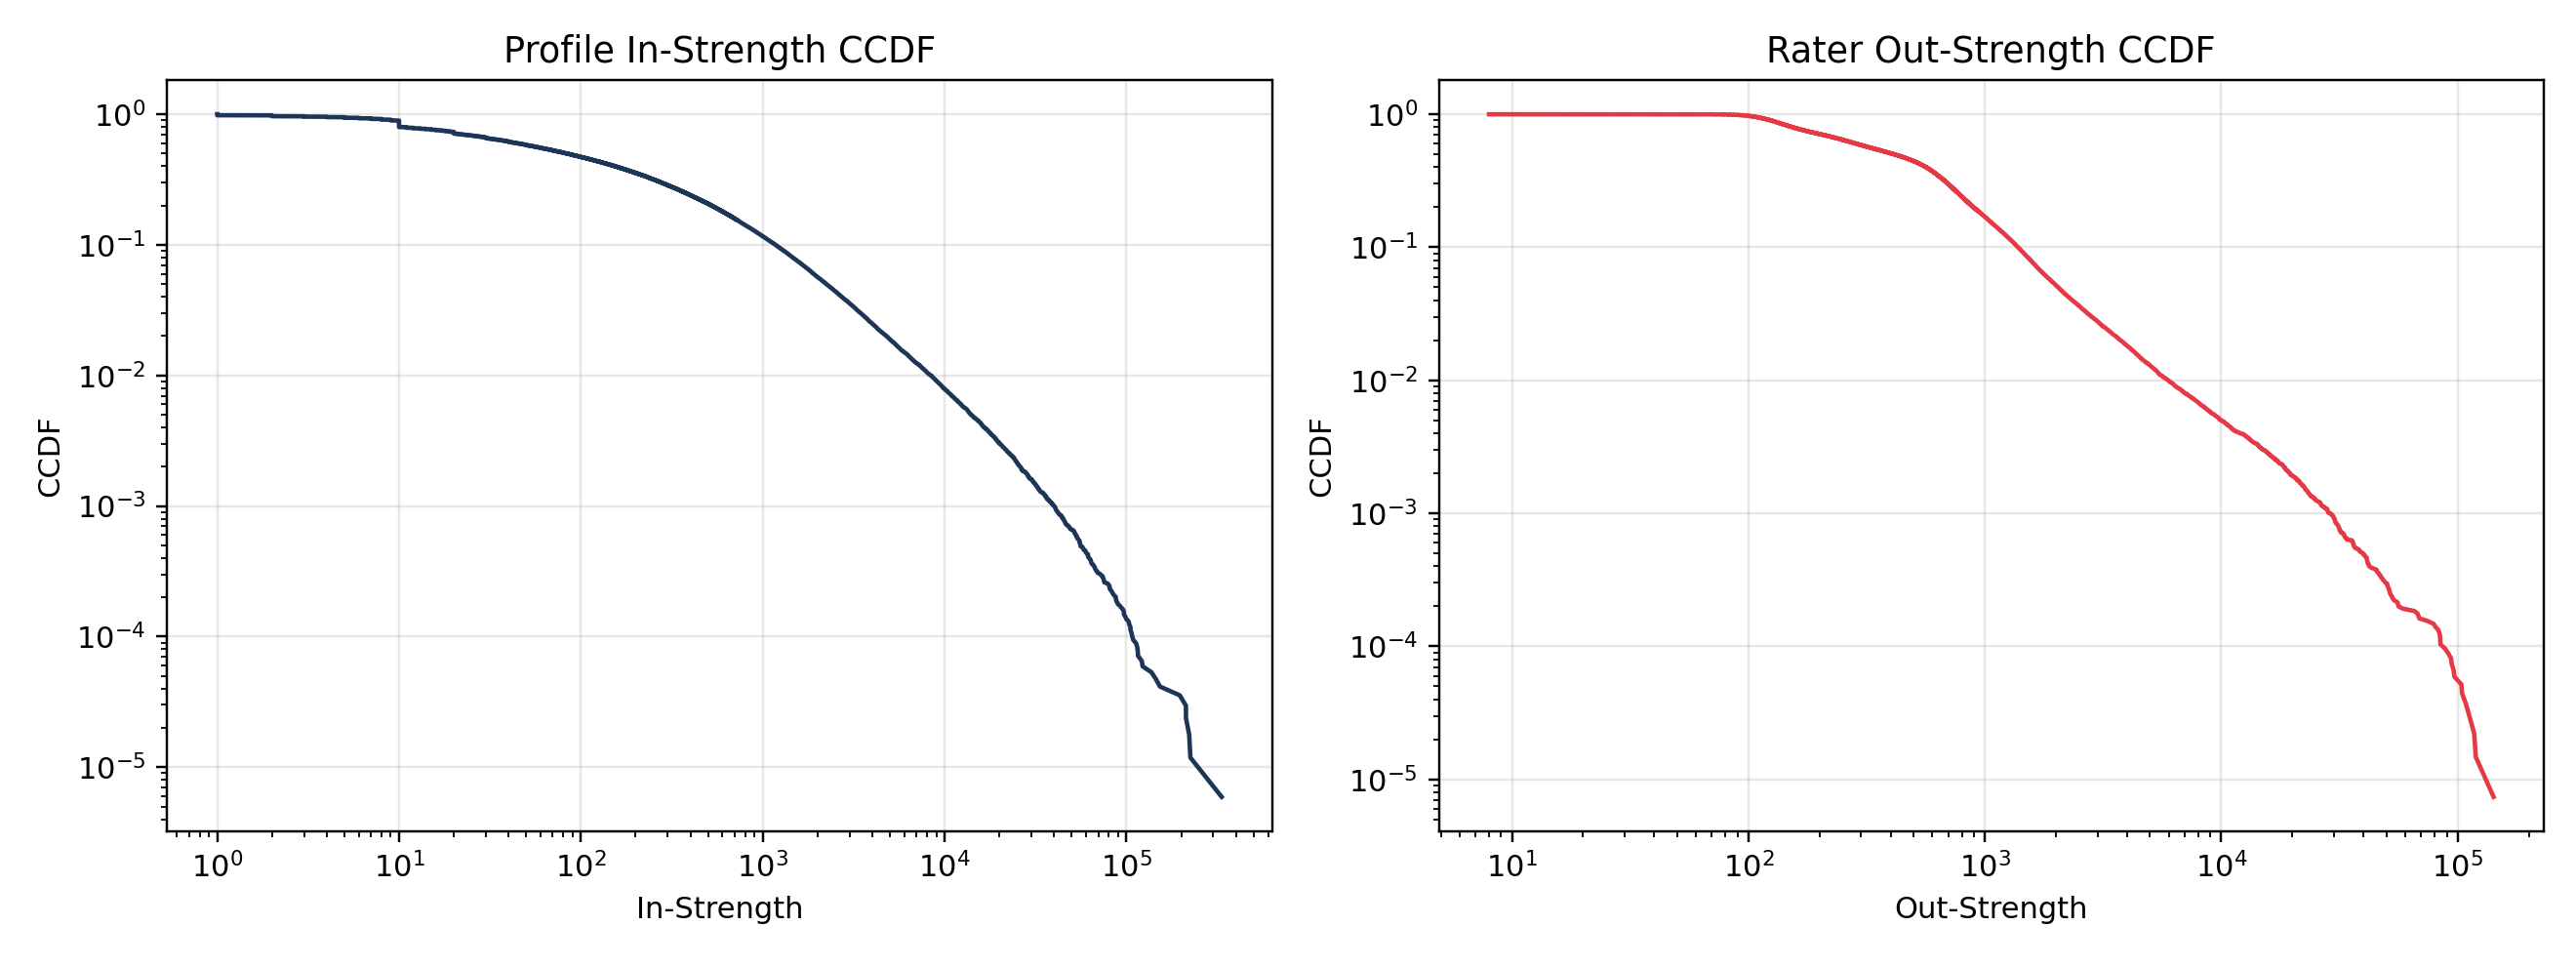

### popularity_vs_prestige_full.png

The raw scatter shows that more popular profiles are usually also more prestigious.

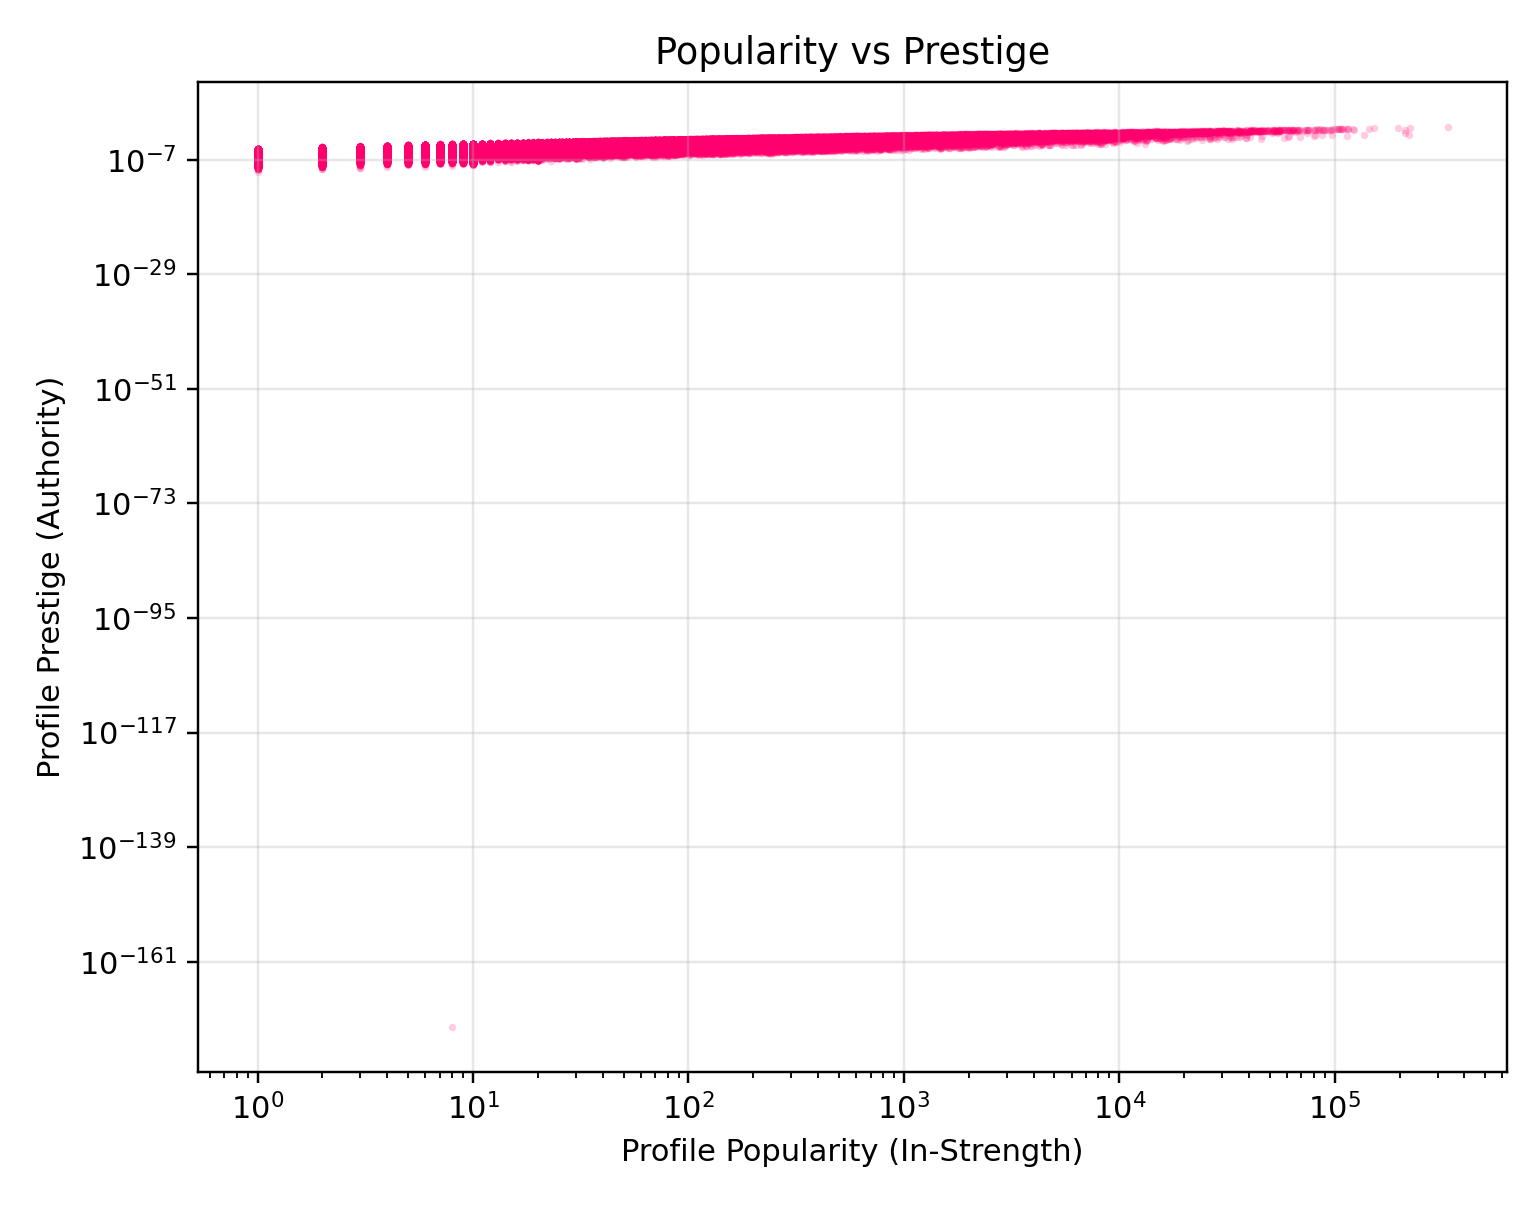

### popularity_vs_prestige_2_full.png

The percentile-binned version gives a cleaner summary of the same relationship.

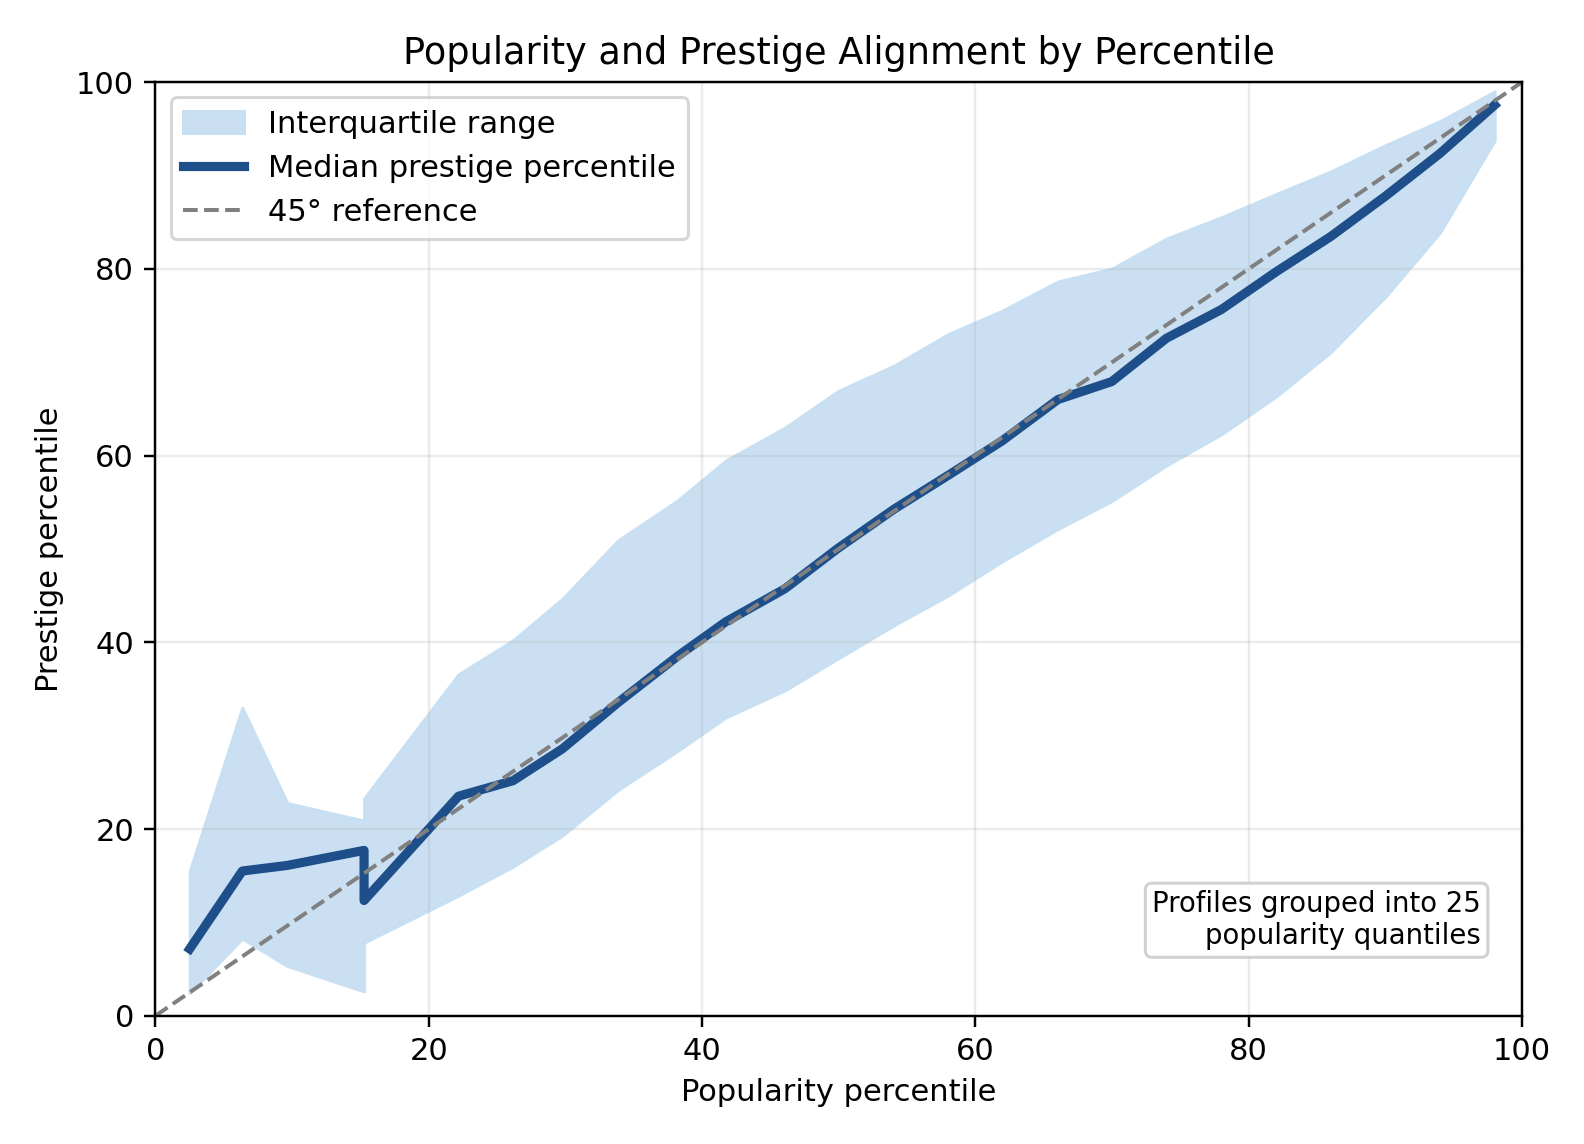

### profile_lorenz_full.png

Both attention and prestige are highly unequal, and raw attention is slightly more concentrated than authority in the summary statistics.

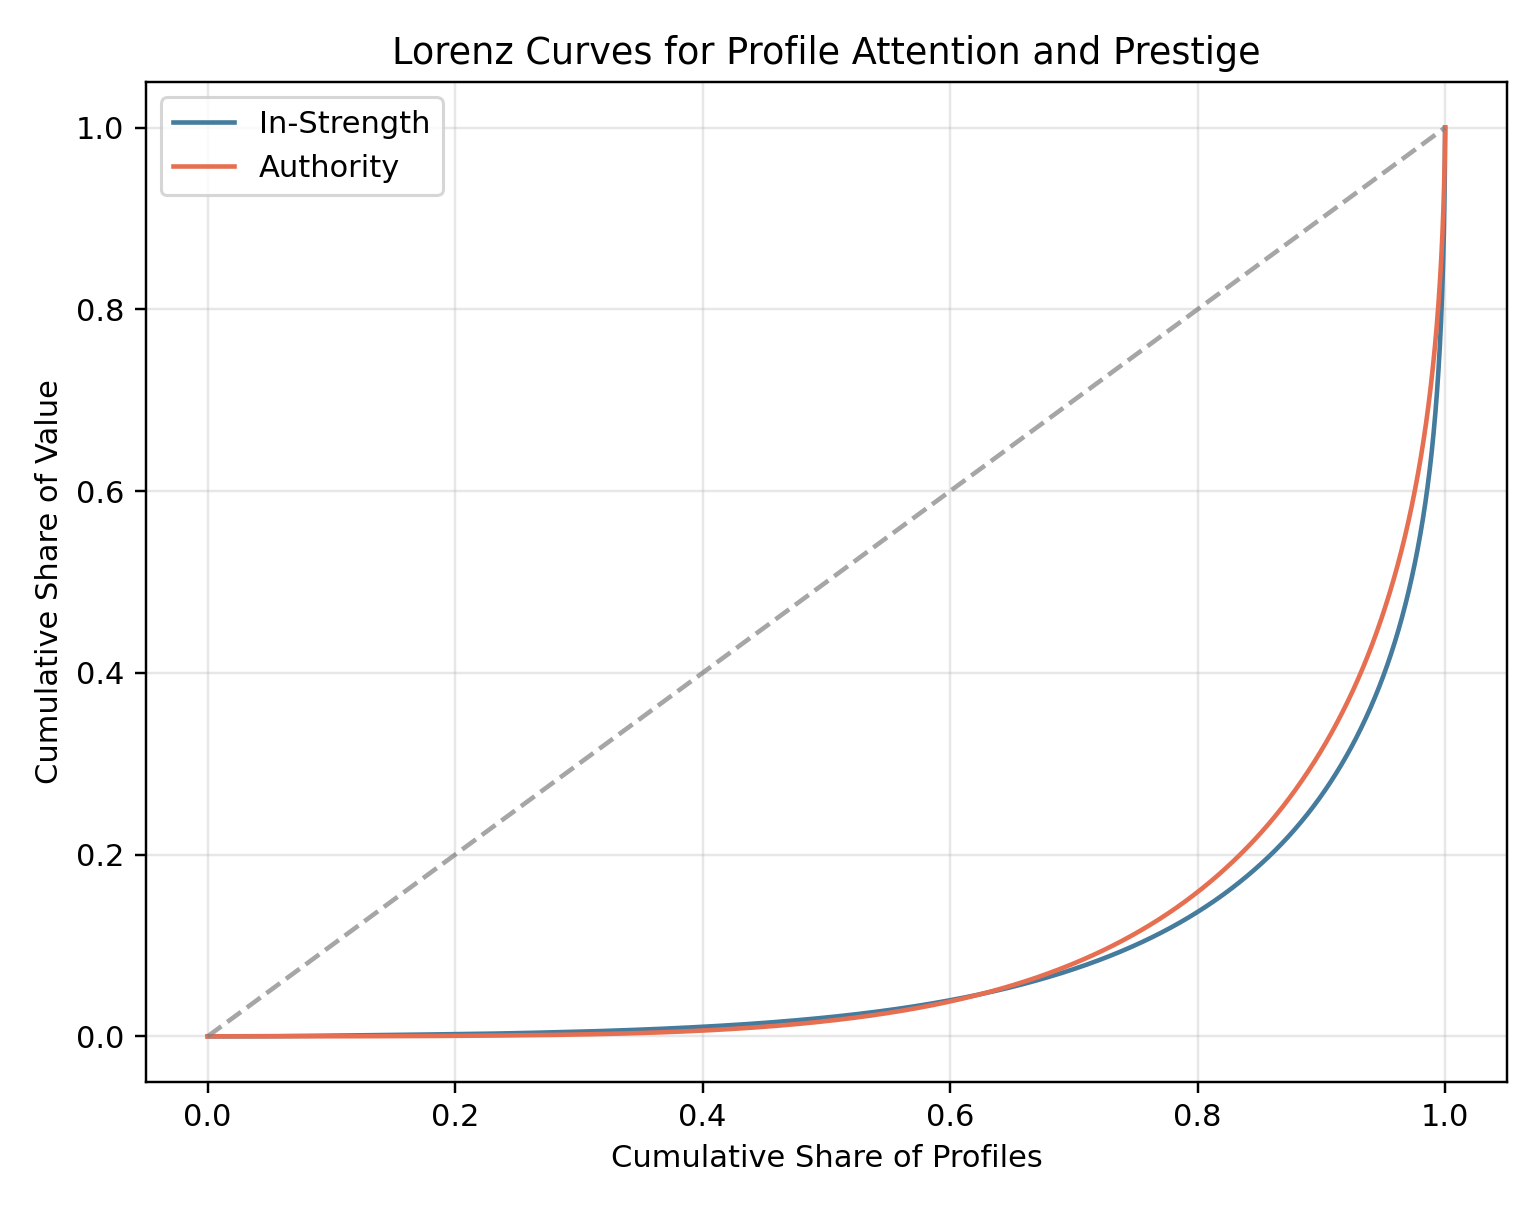

In [3]:
figure_notes = [
    (
        "rating_distribution_full.png",
        "The rating scale is used unevenly, with substantial mass near the upper end.",
    ),
    (
        "strength_ccdf_full.png",
        "Interaction is heavy-tailed on both sides of the bipartite graph, especially on the profile side.",
    ),
    (
        "popularity_vs_prestige_full.png",
        "The raw scatter shows that more popular profiles are usually also more prestigious.",
    ),
    (
        "popularity_vs_prestige_2_full.png",
        "The percentile-binned version gives a cleaner summary of the same relationship.",
    ),
    (
        "profile_lorenz_full.png",
        "Both attention and prestige are highly unequal, and raw attention is slightly more concentrated than authority in the summary statistics.",
    ),
]

for filename, note in figure_notes:
    display(Markdown(f"### {filename}\n\n{note}"))
    display(Image(filename=str(OUTPUT_FIGURES / filename)))


## Concrete Rankings

Exploratory analysis should not stop at correlations.
The tables below show which concrete profiles and raters occupy the most visible positions in the network.


In [4]:
display(Markdown("### Most popular profiles"))
display(top_popularity.head(10))

display(Markdown("### Most prestigious profiles"))
display(top_prestige.head(10))

display(Markdown("### Profiles whose prestige is higher than their popularity rank would suggest"))
display(top_gap_positive.head(10))

display(Markdown("### Profiles whose popularity is higher than their prestige rank would suggest"))
display(top_gap_negative.head(10))

display(Markdown("### Most active raters"))
display(top_raters_activity.head(10))

display(Markdown("### Strongest hub raters"))
display(top_raters_hub.head(10))


### Most popular profiles

,profile_id,in_degree,in_strength,mean_rating,authority_score,popularity_rank_pct,prestige_rank_pct,prestige_gap
0,606,33389,"333,761.0000",9.9961,0.1839,1.0000,1.0000,0.0000
1,228,23639,"224,626.0000",9.5023,0.1291,1.0000,1.0000,0.0000
2,1440,28398,"221,237.0000",7.7906,0.0067,1.0000,0.9856,-0.0144
3,4963,21284,"212,429.0000",9.9807,0.0134,1.0000,0.9952,-0.0047
4,48,21387,"212,227.0000",9.9232,0.0529,1.0000,0.9998,-0.0002
5,320,23649,"196,210.0000",8.2968,0.1214,1.0000,1.0000,0.0000
6,44,18550,"152,752.0000",8.2346,0.1054,1.0000,1.0000,0.0000
7,475,23113,"144,969.0000",6.2722,0.0872,1.0000,1.0000,0.0000
8,1477,16049,"137,160.0000",8.5463,0.0060,1.0000,0.9831,-0.0169
9,479,20634,"122,681.0000",5.9456,0.0525,0.9999,0.9998,-0.0002


### Most prestigious profiles

,profile_id,in_degree,in_strength,mean_rating,authority_score,popularity_rank_pct,prestige_rank_pct,prestige_gap
0,606,33389,"333,761.0000",9.9961,0.1839,1.0000,1.0000,0.0000
1,228,23639,"224,626.0000",9.5023,0.1291,1.0000,1.0000,0.0000
2,320,23649,"196,210.0000",8.2968,0.1214,1.0000,1.0000,0.0000
3,44,18550,"152,752.0000",8.2346,0.1054,1.0000,1.0000,0.0000
4,130,11600,"115,415.0000",9.9496,0.0922,0.9999,1.0000,0.0000
5,20,12185,"121,377.0000",9.9612,0.0904,0.9999,1.0000,0.0000
6,5527,11117,"106,636.0000",9.5922,0.0903,0.9999,1.0000,0.0001
7,475,23113,"144,969.0000",6.2722,0.0872,1.0000,1.0000,0.0000
8,60,12576,"112,989.0000",8.9845,0.0859,0.9999,1.0000,0.0000
9,102,13451,"105,091.0000",7.8129,0.0854,0.9999,0.9999,0.0001


### Profiles whose prestige is higher than their popularity rank would suggest

...

,profile_id,in_degree,in_strength,mean_rating,authority_score,popularity_rank_pct,prestige_rank_pct,prestige_gap
0,32630,223,886.0000,3.9731,0.0000,0.8700,0.2151,-0.6549
1,28002,403,747.0000,1.8536,0.0000,0.8495,0.1952,-0.6543
2,49383,169,989.0000,5.8521,0.0000,0.8824,0.2323,-0.6502
3,60953,118,"1,053.0000",8.9237,0.0000,0.8891,0.2473,-0.6418
4,39027,130,646.0000,4.9692,0.0000,0.8300,0.1916,-0.6384
5,34532,738,"1,476.0000",2.0000,0.0000,0.9207,0.2844,-0.6363
6,61333,108,970.0000,8.9815,0.0000,0.8804,0.2464,-0.6340
7,17838,460,928.0000,2.0174,0.0000,0.8754,0.2422,-0.6332
8,21394,148,"1,480.0000",10.0000,0.0000,0.9210,0.2890,-0.6319
9,21417,408,"1,635.0000",4.0074,0.0000,0.9288,0.2972,-0.6316


### Most active raters

,rater_id,out_degree,out_strength,mean_rating_given,hub_score,activity_rank_pct,hub_rank_pct,hub_gap
0,56793,21599,"141,862.0000",6.5680,0.0749,1.0000,1.0000,0.0000
1,61437,18810,"119,253.0000",6.3399,0.0584,1.0000,1.0000,-0.0000
2,90281,25042,"117,477.0000",4.6912,0.0601,1.0000,1.0000,0.0000
3,72352,18443,"112,227.0000",6.0851,0.0700,1.0000,1.0000,0.0000
4,85633,15419,"108,399.0000",7.0302,0.0577,1.0000,1.0000,-0.0000
5,78821,13769,"104,351.0000",7.5787,0.0559,1.0000,0.9999,-0.0000
6,131977,17560,"103,717.0000",5.9064,0.0432,1.0000,0.9999,-0.0001
7,58766,18197,"96,895.0000",5.3248,0.0429,0.9999,0.9999,-0.0001
8,33640,19908,"96,111.0000",4.8278,0.0539,0.9999,0.9999,-0.0000
9,127228,18342,"94,366.0000",5.1448,0.0560,0.9999,1.0000,0.0000


### Strongest hub raters

,rater_id,out_degree,out_strength,mean_rating_given,hub_score,activity_rank_pct,hub_rank_pct,hub_gap
0,56793,21599,"141,862.0000",6.5680,0.0749,1.0000,1.0000,0.0000
1,72352,18443,"112,227.0000",6.0851,0.0700,1.0000,1.0000,0.0000
2,90281,25042,"117,477.0000",4.6912,0.0601,1.0000,1.0000,0.0000
3,51413,11008,"88,509.0000",8.0404,0.0596,0.9999,1.0000,0.0001
4,61437,18810,"119,253.0000",6.3399,0.0584,1.0000,1.0000,-0.0000
5,85633,15419,"108,399.0000",7.0302,0.0577,1.0000,1.0000,-0.0000
6,127228,18342,"94,366.0000",5.1448,0.0560,0.9999,1.0000,0.0000
7,78821,13769,"104,351.0000",7.5787,0.0559,1.0000,0.9999,-0.0000
8,67218,12560,"80,538.0000",6.4123,0.0544,0.9999,0.9999,0.0001
9,77444,10783,"83,751.0000",7.7669,0.0543,0.9999,0.9999,0.0001


In [5]:
display(
    Markdown(
        f"""
        ## Interpretation

        ### Technical interpretation

        - Popularity and prestige are strongly aligned in the full network (**Pearson = {full_corr['pearson']:.3f}**, **Spearman = {full_corr['spearman']:.3f}**).
        - The alignment remains strong when we restrict the graph to positive ratings of at least 8.
        - The rankings are not identical: the top-100 sets overlap on **{overlap['intersection']}** profiles, not all 100.
        - Both attention and prestige are highly unequal; the inequality summary suggests that **raw attention is slightly more concentrated than authority** in the full-layer outputs.

        ### Plain-language interpretation

        - Profiles that attract a lot of total attention are usually also the profiles that look important in the network structure.
        - Still, the two ideas are not the same thing. Some profiles are helped or hurt by *who* rates them, not just by *how many* ratings they get.
        - A relatively small part of the network captures a very large share of attention.
        """
    )
)



        ## Interpretation

        ### Technical interpretation

        - Popularity and prestige are strongly aligned in the full network (**Pearson = 0.844**, **Spearman = 0.855**).
        - The alignment remains strong when we restrict the graph to positive ratings of at least 8.
        - The rankings are not identical: the top-100 sets overlap on **75** profiles, not all 100.
        - Both attention and prestige are highly unequal; the inequality summary suggests that **raw attention is slightly more concentrated than authority** in the full-layer outputs.

        ### Plain-language interpretation

        - Profiles that attract a lot of total attention are usually also the profiles that look important in the network structure.
        - Still, the two ideas are not the same thing. Some profiles are helped or hurt by *who* rates them, not just by *how many* ratings they get.
        - A relatively small part of the network captures a very large share of attention.
        

## What Comes Next

Exploration gives us the big picture.

The next notebook moves from broad description to **applications**:

- concentration of high and low ratings
- concentration of overall interaction
- feature alignment between the popularity/prestige study and the concentration study
